### Chapter four (Melt model): scripts to make figures

Here, codes to reproduce figures (in their minimal version) are added. I use this also to have the latest figure together, and maybe change some things regarding their styles?



In [1]:

import os
os.chdir('/nfs/mary/Users/eelse/scripts/jupyter')

In [2]:
%matplotlib inline
import xarray as xr
import cartopy.feature
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import cmcrameri.cm as cmc
from matplotlib.colors import BoundaryNorm, TwoSlopeNorm, LinearSegmentedColormap, ListedColormap, Normalize
import matplotlib as mpl

import regionmask
import geopandas as gpd
import pandas as pd
regionmask.__version__
#Yvans
import mw_protocol.plotting as plotting
import mw_protocol.saving as saving
import mw_protocol.glac1d_toolbox as tb
import pylaeoclim_leeds.util_hadcm3 as util

#Mine
import mymodules.myfunc as mf 


colores = {'0':'tab:blue', '1':'tab:orange', '2':'tab:green', '3':'tab:red', '4':'tab:purple', '5':'tab:brown', '6':'tab:pink',
         '7':'tab:olive', '8':'tab:cyan'}

### Methods
#### Fig.1: Underlying simulations, AMOC modes and the four scenarios





In [210]:
# Plot A: the discharge timeseries
ds_discharge = xr.open_dataset(f"{data_folder}/mw_inputs/xoup.wfix.glac_ts.nc",decode_times=False)
ds_lsm = xr.open_dataset(f"{data_folder}/lgm_inputs/temev.qrparm.omask.nc")
ds_wfix = xr.open_dataset(f"{data_folder}/lgm_inputs/qrparm.waterfix.hadcm3.nc")

flux = plotting.create_discharge_ts(ds_discharge, ds_lsm, rmean=None,units="kg/m2/s")
t = ds_discharge.t.values

flux_elwg = flux['elwg']
flux_gin = flux['gin']
flux_arc = flux['arc']

__ Creating discharge time series


In [212]:
## Create dataframe

# Create a DataFrame with 't' and the fluxregions
df = pd.DataFrame({
    't': ds_discharge.t,
    'elwg': flux_elwg.value,
    'gin': flux_gin.value,
    'arc': flux_arc.value,
    'tot': flux['tot'].value
})

In [218]:
# Load MLD Data (test with 17.8k scenario only, i need to make this data shorter

#Load Sea ice
exp_list = ['xpraj','xprak','xpral']

ds_sicec = {}
ds_siced = {}

for expt in exp_list:
    with mf.Timer(f"{expt} sea ice"):
        ds_sicec[expt] = xr.open_dataset(f'/nfs/annie/earpal/database/experiments/{expt}/time_series/{expt}.iceconc.monthly.nc')
        ds_siced[expt] = xr.open_dataset(f'/nfs/annie/earpal/database/experiments/{expt}/time_series/{expt}.icedepth.monthly.nc')
        #ds_bstream = xr.open_dataset('/nfs/annie/earpal/database/experiments/tfgbj/time_series/tfgbj.streamFnpf01.monthly.nc')

#Load Mixed Layer
mld = {}
mld_phase = {}
database = "/nfs/see-fs-01_users/eelse/database"

with mf.Timer(f"amoc"):
    for expt in exp_list:
        mld_phase[expt] = {}
        mld[expt] = xr.open_dataset(
            f"{database}/{expt}/time_series/{expt}.oceanmixedpf.monthly.nc").mixLyrDpth_mm_uo.isel(
            unspecified=0, drop=True)[1:]





[xpraj sea ice]
Elapsed: 0.08617973327636719
[xprak sea ice]
Elapsed: 0.08765578269958496
[xpral sea ice]
Elapsed: 0.09301590919494629
[amoc]
Elapsed: 188.69502425193787


In [222]:
ds_mld = 

ds_mld['cold'] = mld['xpraj'].mean(dim='t')

<xarray.DataArray 'mixLyrDpth_mm_uo' (latitude: 144, longitude: 288)>
array([[ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
         0.      ],
       [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
         0.      ],
       [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
         0.      ],
       ...,
       [21.570868, 21.402416, 21.202482, ..., 21.972208, 21.84983 ,
        21.722097],
       [28.242865, 28.021797, 27.80272 , ..., 28.860018, 28.670666,
        28.471321],
       [ 0.      ,  0.      ,  0.      , ...,  0.      ,  0.      ,
         0.      ]], dtype=float32)
Coordinates:
  * latitude   (latitude) float32 -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * longitude  (longitude) float32 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8

In [ ]:

exp_liste =  {'tfgbj':'17.8ka', 'xoupf':'18.2ka',  'tfgbr_xoupl':'19.4ka','tfgbi':'20.7ka'}

import matplotlib.patches as mpatches
norm = Normalize(vmin=0, vmax=350)
march_patch = mpatches.Patch(color='black', label='max sea ice extent (march)')
sept_patch = mpatches.Patch(color='xkcd:red', label='min sea ice extent (september)')

regime_ls = ('xpraj':'cold','xprak':'zonal','xpral':'merid')


#Map showing seasonal means
from matplotlib import colors

#fig,ax = plt.subplots(nrows=2, ncols=3, figsize=(14,7))
#normsice = Normalize(vmin=0,vmax=1)
#normSSTdiff = colors.TwoSlopeNorm(vmin=-5., vcenter=0., vmax=10)

projection_map = ccrs.NearsidePerspective(central_longitude=-35, central_latitude=45, satellite_height=11000000)
figMap,axMap = plt.subplots(nrows=4, ncols=3, subplot_kw={'projection':projection_map}, figsize=(16,10),dpi=100)
months = (3,9)


for e,expt in enumerate(exp_liste):
    lon_ds, lat_ds = ds_sicec_spans[expt]['cold'].longitude.values, ds_sicec_spans[expt]['cold'].latitude.values
    lon_ds_b, lat_ds_b = tb.create_coordinate_edges(lon_ds), lat_ds


    lon_mld_ds, lat_mld_ds = ds_mld_spans_sm[expt]['cold'].longitude.values, ds_mld_spans_sm[expt]['cold'].latitude.values
    lon_mld_ds_b, lat_mld_ds_b = tb.create_coordinate_edges(lon_mld_ds), lat_mld_ds

    for j,r in enumerate(regime_ls):
        #Zonal simulation
        try:
            axMap[e,j].set_title(f"{exp_liste[expt]} ({expt})\n{r}")
            #cmMLD = axMap[j].contourf(lon_ds, lat_ds, mld_values, transform=ccrs.PlateCarree(), cmap="Greens")
            
            cmap = axMap[e,j].pcolormesh(lon_mld_ds_b,lat_mld_ds_b,
                      np.where(ds_mld_spans[expt][r].mean("t")==0, np.nan, ds_mld_spans[expt][r].mean("t")),
                      cmap='Greens', norm=norm, 
                                transform=ccrs.PlateCarree())
            
            axMap[e,j].contour(lon_ds, lat_ds,ds_sicec_spans_sm[expt][r]['iceconc_mm_srf'].sel(month=3).isel(surface=0), transform=ccrs.PlateCarree(), 
                                #norm=normSST, cmap=cmc.navia, 
                                       levels=[0.5], colors='black',
                      linewidths=1.2, linestyles='-',alpha=1)
            axMap[e,j].contour(lon_ds, lat_ds,ds_sicec_spans_sm[expt][r]['iceconc_mm_srf'].sel(month=9).isel(surface=0), transform=ccrs.PlateCarree(), 
                                #norm=normSST, cmap=cmc.navia, 
                                       levels=[0.5], colors='xkcd:red',
                      linewidths=1.2, linestyles='--',alpha=1)
            axMap[e,j].pcolormesh(lsm.longitude, lsm.latitude,xr.where(lsm==0, np.nan,lsm),
                      cmap=ListedColormap(['xkcd:pale brown']), transform=ccrs.PlateCarree(),
                      zorder=1)
        except:
            print('skip {r}, {expt}')
    plt.legend(handles=[march_patch,sept_patch],loc="lower center")
plt.tight_layout()
cb = plt.colorbar(cmap,ax=axMap)
cb.set_label(f"Mixed layer depth [m]", size='small')
cb.ax.tick_params(labelsize='small')



Text(0, 0.5, 'Total melt discharge (Sv)')

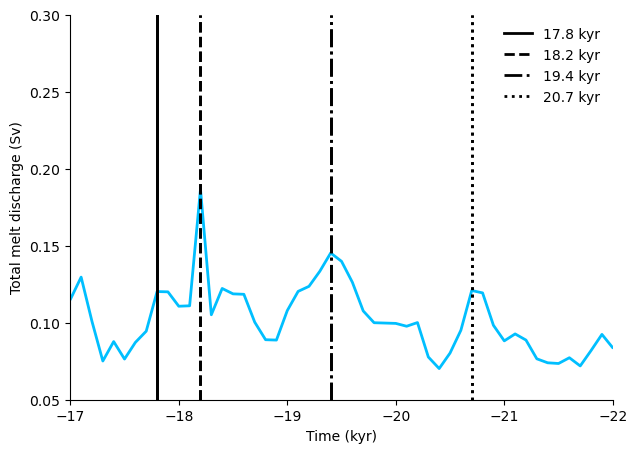

In [216]:
# Plot
fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(df["t"]/1000, df["tot"], color="deepskyblue", linewidth=2)

# Interpolation times (the ones you want to mark)
highlight_times = np.array([-17800, -18200, -19400, -20700])

# Interpolate values at those times
interpolated_values = np.interp(highlight_times, df["t"], df["tot"])

# 🔹 Vertical snapshot lines with different styles
line_styles = ["-", "--", "-.", ":"]

for t, ls in zip(highlight_times, line_styles):
    ax.axvline(x=t/1000, color="black", linestyle=ls, linewidth=2)

# Reversed x-axis ⏪
ax.set_xlim(-17, -22)
ax.set_ylim(0.05, 0.3)

# Remove top and right borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_axisbelow(True)

# Labels
labels = ["17.8 kyr", "18.2 kyr", "19.4 kyr", "20.7 kyr"]
for t, ls, lab in zip(highlight_times, line_styles, labels):
    ax.axvline(x=t/1000, color="black", linestyle=ls, linewidth=2, label=lab)

ax.legend(frameon=False)

ax.set_xlabel("Time (kyr)")
ax.set_ylabel("Total melt discharge (Sv)")

In [ ]:
#Load necessary data
#Load Spans
exp_liste =  {'tfgbj':'17.8ka', 'xoupf':'18.2ka',  'tfgbr_xoupl':'19.4ka','tfgbi':'20.7ka'}
span_conditions, spans = {}, {}

for expt in exp_liste:
    with mf.Timer(f'{expt} load'):
        span_conditions[expt], spans[expt] = {}, {}
        data_folder = f"/nfs/see-fs-01_users/eelse/database/{expt}/perso/spans"
    
        for phase in ['cold', 'warming', 'merid', 'zonal', 'cooling']:
            span_conditions[expt][phase] = np.load(f"{data_folder}/{expt}.span_condition.{phase}.npy")
            spans[expt][phase] = np.load(f"{data_folder}/{expt}.spans.{phase}.npy")


#AMOC time series
amoc_ts = {}
amocf_ts = {}
filt = util.ButterLowPass(order=1, fc=2*10**-3, fs=1, mult=2)


for expt in exp_liste:
  with mf.Timer(f'{expt} AMOC load'):
    ts_full = xr.open_dataset(f"/nfs/see-fs-01_users/eelse/database/{expt}/time_series/{expt}.merid.annual.nc")
    ts = ts_full.drop_duplicates(dim='t')
    amoc_ts[expt] = ts.Merid_Atlantic.sel(latitude=26.5, method='nearest').max('depth').sortby('t')
    amocf_ts[expt] = filt.process(amoc_ts[expt].values)



In [4]:
import matplotlib.gridspec as gridspec
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import AutoMinorLocator, FuncFormatter, FormatStrFormatter, MultipleLocator

color_spans = {'cold':'#484A6C', 
               'warming':'#FFABAB',
               'merid':'#C9381B', 
               'zonal':'#F59F00', 
               'cooling':'#B7DDF6'}

color_expts = {'xoupa':'black', 
              'xouph':'xkcd:bluey grey', 
              'xoupf':'xkcd:bluish', 
              'xoupk':'xkcd:bluish', 'tfgbi':'xkcd:bluish', 'tfgbj':'xkcd:bluish','tfgbr_xoupl':'xkcd:bluish',
               'xppbe':'xkcd:purple',
               'xppbf':'xkcd:bluish green'}

label_expts = {'xoupa':'CTRL', 
               'xouph':'21k', 
               'tfgbi':'20.7k', 
               'xoupk':'20.7k_tdc', 
               'tfgbr_xoupl':'19.4k',
               'xoupf':'18.2k',
               'xppbe':'20.7k with 21k GST',
               'xppbf':'20.7_no_gst',
               'tfgbj':'17.8k'}

modelyears_fordye = {}
modelyears_fordye['tfgbj']={'cold':[[4681,5180]], 
                       'merid':[[5381,5880],[3511,4011]], 
                       'zonal':[[4101,4601]]}
modelyears_fordye['tfgbi']={'cold':[[8395,8721]], 
                       'merid':[[7277,7523]], 
                       'zonal':[[7523,8185]]}
modelyears_fordye['xoupf']={'cold':[[6000, 6500]], 
                       'merid':[[7323, 7629]]}
modelyears_fordye['tfgbr_xoupl']={'cold':[[7759, 8233]],
                                  'merid':[[6940, 7155]],
                                'zonal': [[7155, 7535]] 
                                 }


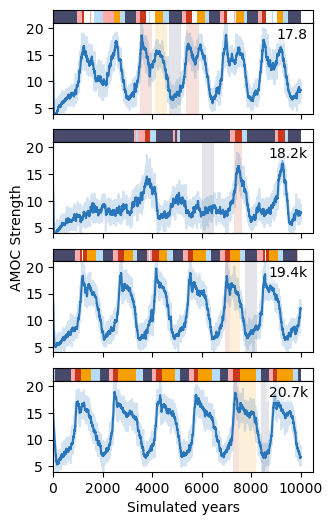

In [32]:
#Plot the plot
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

exp_liste =  {'tfgbj':'17.8', 'xoupf':'18.2k',  'tfgbr_xoupl':'19.4k','tfgbi':'20.7k'}

# Create figure and grid specification
fig = plt.figure(figsize=(4, 6))

# Define the grid layout
grid = fig.add_gridspec(4, 1, hspace=0.15)

# Create subplots
for i,expt in enumerate(exp_liste):
    #expt= exp_liste[i]
    # Define the inner grid layout for each row
    inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=grid[i], height_ratios=[1, 7],hspace=0)

    # Add subplots for each row
    upper_ax = fig.add_subplot(inner_grid[0])
    for phase in spans[expt].keys():
        plt.imshow(np.expand_dims(span_conditions[expt][phase], axis=0), aspect='auto',
                                cmap = ListedColormap(['None', color_spans[phase]]),alpha=1)
    
    
    lower_ax = fig.add_subplot(inner_grid[1],sharex=upper_ax)
    for phase in modelyears_fordye[expt].keys():
        for span in modelyears_fordye[expt][phase]:
            plt.axvspan(span[0], span[1], alpha=0.15, linewidth=0, color=color_spans[phase])
        #plt.imshow(np.expand_dims(span_conditions[expt][phase], axis=0), aspect='auto',
         #                       cmap = ListedColormap(['None', color_spans[phase]]),alpha=0.15)
    plt.plot(amoc_ts[expt].t.dt.year-1000, util.rmean(amoc_ts[expt],30), color=color_expts[expt])
    plt.plot(amoc_ts[expt].t.dt.year-1000, amoc_ts[expt], color=color_expts[expt], alpha=0.2)
    # Remove x-axis labels
    upper_ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    upper_ax.set_yticklabels([])
    #upper_ax.tick_params(axis='y', which='both', bottom=False, top=False, labelbottom=False)
    #lower_ax.invert_yaxis()
    # Upper ax: remove all y-axis ticks and labels
    upper_ax.set_yticks([])

    # Lower ax: set y-tick spacing of 2
    lower_ax.yaxis.set_major_locator(plt.MultipleLocator(5))
    lower_ax.set_ylim(4,21)
    
    # Customize subplots if needed
    lower_ax.text(
    0.98, 0.95,                  # x, y in axes coordinates (0=left/bottom, 1=right/top)
    f"{exp_liste[expt]}",
    transform=lower_ax.transAxes,
    va='top', ha='right',
    bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=2),
    )
    if (i < 3):
        lower_ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False)
    else:
        lower_ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
        lower_ax.set_xlabel('Simulated years')


    #lower_ax.set_ylabel('AMOC strength')
    #lower_ax.set_xlabel('Model years')
    #upper_ax.
    #lower_ax.set_title(f"Lower Section Row {i+1}")
    #lower_ax[2].set_xaxis('Model years')
# Show the plot
#plt.tight_layout()
#plt.show()

# Adjust layout to make space for the ylabel
plt.subplots_adjust(left=0.15, right=0.8, hspace=0.3)

# Set the ylabel spanning multiple rows
fig.text(0.06, 0.5, 'AMOC Strength', ha='center', va='center', rotation='vertical')




plt.savefig("my_output/chapter-four_latestfigures/01_underlyingsim.pdf")




#### Fig.2: Region Setup and Region Discharge

In [151]:
#Load Data
#Land Sea Mask
#landmask
with mf.Timer('Land sea mask loader'):
    data_folder = f"/nfs/annie/eeymr/work/data/publication/ROME2022_paleoceanography_oscillations"
    ds_lsm = xr.open_dataset(f"{data_folder}/lgm_inputs/temev.qrparm.omask.nc")
    lsm = ds_lsm.lsm
    lon_lsm, lat_lsm = ds_lsm.longitude.values, ds_lsm.latitude.values
    lon_lsm_b, lat_lsm_b = tb.create_coordinate_edges(lon_lsm), lat_lsm
#lsm = ds_lsm.lsm
#ds_lsm

#Regions
ds_dye = xr.open_dataset('myintermediates/dyestuff_modelpaper/dye_regions_norm.nc')
dyen = list(ds_dye.data_vars)

#Regionfluxes
gdf = pd.read_pickle('myintermediates/gdf_regions.pkl')

# Batchelor Ice sheet reconstruction
#LGM Shapefile
# Path to your shapefile (.shp)
shapefile_path = '/nfs/mary/Users/eelse/work/ice_reconstruct_data/LGM_Batchelor2019_ice-sheet-extent'

# Read the shapefile using GeoPandas
gdf_lgm = gpd.read_file(shapefile_path)





[Land sea mask loader]
Elapsed: 0.0895235538482666


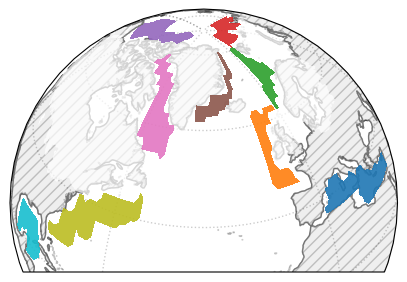

In [63]:
#Plot
import cartopy.feature as cfeature
#Plot A

projection_map = ccrs.Robinson()
projection_map = ccrs.NearsidePerspective(central_longitude=-35, central_latitude=45, satellite_height=11000000)

figMap,axMap = plt.subplots(nrows=1, ncols=1, subplot_kw={'projection':projection_map}, figsize=(5,5))
#axMap = axMap.flatten()
#normDis = Normalize(vmin=0,vmax= 2e-5)
minlev=0
lev = 0.001

#cmap = plt.get_cmap('rainbow')
#cmap.set_under('white')  # Color for values less than vmin
eps = np.spacing(0.0)




for i,d in enumerate(dyen[1:]):
    axMap.contourf(lon_lsm, lat_lsm,ds_dye[d].clip(min=eps).isel(t=0,depth=0), transform=ccrs.PlateCarree(), 
                                          levels=[0.1, 1],colors=colores[f'{i}'],zorder=10,alpha=0.9)
 
#axMap.pcolormesh(lsm.longitude, lsm.latitude,xr.where(lsm==0, np.nan,lsm),
#              cmap=ListedColormap(['xkcd:pale brown']), transform=ccrs.PlateCarree(),
#              zorder=1,alpha=0.2)
# --- Add hatched land ---
land = cfeature.NaturalEarthFeature(
    'physical', 'land', '50m',
    edgecolor='k',
    facecolor='none'
)
axMap.add_feature(land, facecolor='#CCCCCC', hatch='///', edgecolor='0.3', zorder=2,alpha=0.3)

axMap.coastlines(alpha=0.5)
#axMap.gridlines()
axMap.gridlines(crs=ccrs.PlateCarree(), linewidth=1, color='black', alpha=0.2, linestyle=':', draw_labels=False)


# Plot the shapefile on the map
# `gdf.plot()` is used to plot geometries from the shapefile
#
gdf_lgm = gdf_lgm.to_crs(projection_map.proj4_init)
gdf_lgm.plot(ax=axMap, facecolor='#FFFFFF',
             #hatch='...',
             #edgecolor='darkblue',
             alpha=0.7, zorder=4)



    #axMap.set_global()
    #axMap.set_title(f"Discharge {sce}")
#plt.savefig("temp_output/fig1a.png")

plt.savefig("my_output/chapter-four_latestfigures/regions_v2_b.pdf")


In [152]:
ds_dye

<xarray.Dataset>
Dimensions:    (latitude: 144, longitude: 288, t: 1, depth: 1)
Coordinates:
  * longitude  (longitude) float32 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * latitude   (latitude) float32 -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * t          (t) object 1800-12-01 00:00:00
  * depth      (depth) float32 5.0
Data variables:
    lsm        (latitude, longitude) float32 ...
    Med        (t, depth, latitude, longitude) float32 ...
    Bri        (t, depth, latitude, longitude) float32 ...
    Fen        (t, depth, latitude, longitude) float32 ...
    EurArc     (t, depth, latitude, longitude) float32 ...
    AmeArc     (t, depth, latitude, longitude) float32 ...
    GIS        (t, depth, latitude, longitude) float32 ...
    NLau       (t, depth, latitude, longitude) float32 ...
    SLau       (t, depth, latitude, longitude) float32 ...
    GulofMex   (t, depth, latitude, longitude) float32 ...

### Gradient Dyes

In [10]:
# Mean Datafields

#ds_dye_zonal = xr.open_dataset('myintermediates/dyestuff_modelpaper/mean_dye_zonal.nc')
#ds_dye_cold = xr.open_dataset('myintermediates/dyestuff_modelpaper/mean_dye_cold.nc')
#ds_dye_merid = xr.open_dataset('myintermediates/dyestuff_modelpaper/mean_dye_merid.nc')


#merid mode (17.8,18.2,19.4,20.7)
exp_list = ('xpral','xpujm','xpujj','xpujg')
ds_dye = {}

with mf.Timer('data loading'):
    for exp in exp_list:
        ds_dye[exp] = xr.open_mfdataset(f'/nfs/annie/earpal/database/experiments/{exp}/time_series/{exp}.dye0?.annual.nc',parallel=True)

        old_name=list(ds_dye[exp].data_vars)
        ds_dye[exp] = ds_dye[exp].rename_vars({old_name[0]: 'dye00',
                                        old_name[1]: 'dye01',
                                        old_name[2]: 'dye02',
                                        old_name[3]: 'dye03',
                                        old_name[4]: 'dye04',
                                        old_name[5]: 'dye05',
                                        old_name[6]: 'dye06',
                                        old_name[7]: 'dye07',
                                        old_name[8]: 'dye08',
                                        #old_name[9]: 'dye09',
                                              }
                                             )


/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


[data loading]
Elapsed: 131.42105293273926


In [18]:
ds_dye_merid_mean =  {}

for exp in exp_list:
    ds_dye_merid_mean[exp] = ds_dye[exp].isel(t=slice(150,200),depth_1=0).mean(dim='t')
    # sum across all dye variables
    dye_vars = [v for v in ds_dye_merid_mean[exp].data_vars if v.startswith("dye")]

    ds_dye_merid_mean[exp]["sum_dye"] = ds_dye_zonal[dye_vars].to_array(dim="dye").sum(dim="dye")

    

In [51]:
# Percentages of the total signal 
import pandas as pd
gdg = pd.read_pickle("myintermediates/regionalmeltdischarge_withd18O.pkl") # source region d18O

for sce in ['17.8ka','18.2 ka','19.4 ka','20.7 ka']:
    gdg[f'Meltfraction {sce}'] = gdg[f'Region Melt {sce} (Sv)']/gdg[f'Region Melt {sce} (Sv)'].sum()


#landmask
with mf.Timer('Land sea mask loader'):
    data_folder = f"/nfs/annie/eeymr/work/data/publication/ROME2022_paleoceanography_oscillations"
    ds_lsm = xr.open_dataset(f"{data_folder}/lgm_inputs/temev.qrparm.omask.nc")
    lsm = ds_lsm.lsm
    lon_lsm, lat_lsm = ds_lsm.longitude.values, ds_lsm.latitude.values
    lon_lsm_b, lat_lsm_b = tb.create_coordinate_edges(lon_lsm), lat_lsm



[Land sea mask loader]
Elapsed: 0.2206881046295166


In [45]:
sce_names = ['17.8ka','18.2 ka','19.4 ka','20.7 ka']

for n, exp in enumerate(exp_list):
    sce = sce_names[n]
    ds_dye_merid_mean[exp]['sum_dye_scaled'] = (
        gdg.loc[gdg.Name == 'British', f'Meltfraction {sce}'].iloc[0] * ds_dye_merid_mean[exp]['dye01'] +
        gdg.loc[gdg.Name == 'Fennoscandia', f'Meltfraction {sce}'].iloc[0] * ds_dye_merid_mean[exp]['dye02'] +
        gdg.loc[gdg.Name == 'Mediterranean', f'Meltfraction {sce}'].iloc[0] * ds_dye_merid_mean[exp]['dye00'] +
        gdg.loc[gdg.Name == 'Eurasian Arctic', f'Meltfraction {sce}'].iloc[0] * ds_dye_merid_mean[exp]['dye03'] +
        gdg.loc[gdg.Name == 'American Arctic', f'Meltfraction {sce}'].iloc[0] * ds_dye_merid_mean[exp]['dye04'] +
        gdg.loc[gdg.Name == 'GIS', f'Meltfraction {sce}'].iloc[0] * ds_dye_merid_mean[exp]['dye05'] +
        gdg.loc[gdg.Name == 'N Laurentide', f'Meltfraction {sce}'].iloc[0] * ds_dye_merid_mean[exp]['dye06'] +
        gdg.loc[gdg.Name == 'S Laurentide', f'Meltfraction {sce}'].iloc[0] * ds_dye_merid_mean[exp]['dye07'] +
        gdg.loc[gdg.Name == 'Gulf of Mexico', f'Meltfraction {sce}'].iloc[0] * ds_dye_merid_mean[exp]['dye08']
    ).compute()  

 

In [91]:
ds_dye_merid_mean[exp]['sum_dye_scaled']

<xarray.DataArray 'sum_dye_scaled' (latitude: 144, longitude: 288)>
array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [0.04154458, 0.04173692, 0.04192157, ..., 0.04093434, 0.04114314,
        0.04134639],
       [0.04059437, 0.04070769, 0.04081975, ..., 0.04024881, 0.04036467,
        0.04047995],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], dtype=float32)
Coordinates:
    depth_1    float32 5.0
  * latitude   (latitude) float32 -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * longitude  (longitude) float32 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8

In [92]:
lon_min, lon_max = -80, 0
lat_min, lat_max = 20, 65

# Sum of the dye
merid_na_sum = {}
for n, exp in enumerate(exp_list):
    merid_na_sum[exp] = ds_dye_merid_mean[exp]['sum_dye_scaled'].sel(latitude=slice(lat_min,lat_max),longitude=slice(lon_min,lon_max)).mean()

    

{'xpral': <xarray.DataArray 'sum_dye_scaled' ()>
 array(0.00804243, dtype=float32)
 Coordinates:
     depth_1  float32 5.0,
 'xpujm': <xarray.DataArray 'sum_dye_scaled' ()>
 array(0.00392491, dtype=float32)
 Coordinates:
     depth_1  float32 5.0,
 'xpujj': <xarray.DataArray 'sum_dye_scaled' ()>
 array(0.00651849, dtype=float32)
 Coordinates:
     depth_1  float32 5.0,
 'xpujg': <xarray.DataArray 'sum_dye_scaled' ()>
 array(0.00546647, dtype=float32)
 Coordinates:
     depth_1  float32 5.0}

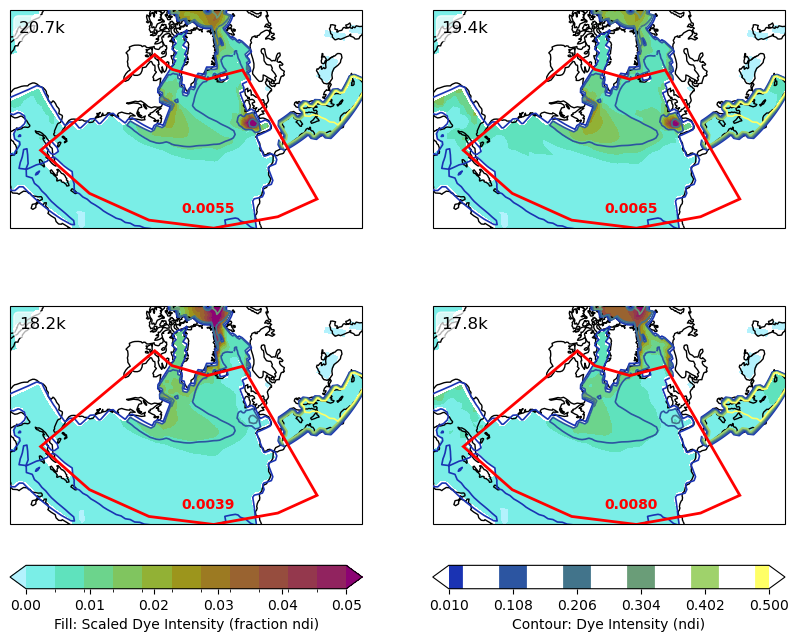

In [102]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import matplotlib.ticker as mticker

# scenarios
exp_n = ["17.8k", "18.2k", "19.4k", "20.7k"]
exp_list = ["xpral", "xpujm", "xpujj", "xpujg"]

import matplotlib.patches as mpatches
# coordinates for the rectangle
lon_min, lon_max = -80, 0
lat_min, lat_max = 20, 65


proj = ccrs.NorthPolarStereo(central_longitude=-30)

fig = plt.figure(figsize=(10, 8))
# 3 rows: 2 for plots, 1 for colorbars
gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 0.08], hspace=0.02, figure=fig)

# create axes for plots
axes = [fig.add_subplot(gs[i//2, i%2], projection=proj) for i in range(4)]

# reversed order
exp_order = [3, 2, 1, 0]  # top-left = last experiment

for ax, idx in zip(axes, exp_order):
    exp = exp_list[idx]
    name = exp_n[idx]

    ax.set_extent([-95, 15, 20, 90], crs=ccrs.PlateCarree())
    ax.coastlines(zorder=10)

    # filled contour
    cf = ds_dye_merid_mean[exp]["sum_dye_scaled"].plot.contourf(
        ax=ax,
        cmap=cmc.hawaii_r,
        levels=12,
        vmin=0, vmax=0.05,
        transform=ccrs.PlateCarree(),
        add_colorbar=False
    )

    # line contours
    cs = ds_dye_merid_mean[exp]["sum_dye"].plot.contour(
        ax=ax,
        cmap=cmc.imola,
        linewidths=1.2,   # thicker lines for visibility
        levels=6,
        vmin=0.01, vmax=0.5,
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
        zorder=15
    )

    # experiment label box
    ax.set_title("")
    ax.text(
        0.025, 0.95, f"{name}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=12,
        bbox=dict(facecolor="white", edgecolor="white", boxstyle="round,pad=0.3", alpha=0.7),
        zorder=30
    )

    # add red rectangle
    width = lon_max - lon_min
    height = lat_max - lat_min
    rect = mpatches.Rectangle(
        (lon_min, lat_min), width, height,
        linewidth=2, edgecolor='red', facecolor='none',
        transform=ccrs.PlateCarree(), zorder=50
    )
    ax.add_patch(rect)

    # --- add average value inside the rectangle (bottom-right corner) ---
    avg_val = merid_na_sum[exp]  # your variable
    ax.text(
        -30, 25, f"{avg_val:.4f}",  # place at bottom-right of rectangle
        color='red', fontsize=10, fontweight='bold',
        ha='center', va='center',
        transform=ccrs.PlateCarree(),
        zorder=60
    )

# --- colorbars below the plots ---
cbar_ax_cf = fig.add_subplot(gs[2, 0])
cbar_ax_cs = fig.add_subplot(gs[2, 1])

# filled contour colorbar (only upper limit extended)
cbar_cf = fig.colorbar(cf, cax=cbar_ax_cf, orientation='horizontal', extend='max')
cbar_cf.set_label("Fill: Scaled Dye Intensity (fraction ndi)")
cbar_cf.set_ticks([0, 0.01, 0.02, 0.03, 0.04, 0.05])  # readable ticks
cbar_cf.ax.tick_params(labelsize=10)

# line contour colorbar (both ends extended)
cbar_cs = fig.colorbar(cs, cax=cbar_ax_cs, orientation='horizontal', extend='both')
cbar_cs.set_label("Contour: Dye Intensity (ndi)")
cbar_cs.ax.tick_params(labelsize=10)
# make lines thicker in colorbar
for t in cbar_cs.ax.collections:
    t.set_linewidth(20)


plt.savefig('my_output/chapter-four_latestfigures/scenario_gradient_dye.pdf')




### Colored Dyes

In [72]:
# Mean Datafields

ds_dye_zonal = xr.open_dataset('myintermediates/dyestuff_modelpaper/mean_dye_zonal.nc')
ds_dye_cold = xr.open_dataset('myintermediates/dyestuff_modelpaper/mean_dye_cold.nc')
ds_dye_merid = xr.open_dataset('myintermediates/dyestuff_modelpaper/mean_dye_merid.nc')

# Regions
with mf.Timer('region data loading'):
    #for exp in exp_list:
        #try:
            ds_region = xr.open_mfdataset(f'/nfs/annie/eelse/my_ancil/dyeregions_v2_netcdf/*.nc',parallel=True)
    
            old_name=list(ds_region.data_vars)


[region data loading]
Elapsed: 0.3977518081665039


In [73]:
# Make the three groups

ds_dye_zonal['EIS'] = ds_dye_zonal['dye01'] + ds_dye_zonal['dye02']  + ds_dye_zonal['dye00'] 
ds_dye_zonal['ARCTIC'] = ds_dye_zonal['dye03'] + ds_dye_zonal['dye04']+ ds_dye_zonal['dye05'] 
ds_dye_zonal['LAU'] = ds_dye_zonal['dye06'] + ds_dye_zonal['dye07'] + ds_dye_zonal['dye08']

ds_dye_cold['EIS'] = ds_dye_cold['dye01'] + ds_dye_cold['dye02']  + ds_dye_cold['dye00'] 
ds_dye_cold['ARCTIC'] = ds_dye_cold['dye03'] + ds_dye_cold['dye04']+ ds_dye_zonal['dye05'] 
ds_dye_cold['LAU'] = ds_dye_cold['dye06'] + ds_dye_cold['dye07'] + ds_dye_cold['dye08']

ds_dye_merid['EIS'] = ds_dye_merid['dye01'] + ds_dye_merid['dye02']  + ds_dye_merid['dye00'] 
ds_dye_merid['ARCTIC'] = ds_dye_merid['dye03'] + ds_dye_merid['dye04']+ ds_dye_zonal['dye05'] 
ds_dye_merid['LAU'] = ds_dye_merid['dye06'] + ds_dye_merid['dye07'] + ds_dye_merid['dye08']


In [74]:
# Percentages of the total signal 
import pandas as pd
gdg = pd.read_pickle("myintermediates/regionalmeltdischarge_withd18O.pkl") # source region d18O

for sce in ['17.8ka','18.2 ka','19.4 ka','20.7 ka']:
    gdg[f'Meltfraction {sce}'] = gdg[f'Region Melt {sce} (Sv)']/gdg[f'Region Melt {sce} (Sv)'].sum()



In [75]:
for sce in ['17.8ka','18.2 ka','19.4 ka','20.7 ka']:

    ds_dye_cold[f'EIS {sce}'] = gdg.loc[gdg.Name == 'British', f'Meltfraction {sce}'].iloc[0]*ds_dye_cold['dye01'] + gdg.loc[gdg.Name == 'Fennoscandia', f'Meltfraction {sce}'].iloc[0]*ds_dye_cold['dye02']  + gdg.loc[gdg.Name == 'Mediterranean', f'Meltfraction {sce}'].iloc[0]*ds_dye_cold['dye00'] 
    ds_dye_cold[f'ARCTIC {sce}'] = gdg.loc[gdg.Name == 'Eurasian Arctic', f'Meltfraction {sce}'].iloc[0]*ds_dye_cold['dye03'] + gdg.loc[gdg.Name == 'American Arctic', f'Meltfraction {sce}'].iloc[0]*ds_dye_cold['dye04']+ gdg.loc[gdg.Name == 'GIS', f'Meltfraction {sce}'].iloc[0]*ds_dye_cold['dye05'] 
    ds_dye_cold[f'LAU {sce}'] = gdg.loc[gdg.Name == 'N Laurentide', f'Meltfraction {sce}'].iloc[0]*ds_dye_cold['dye06'] + gdg.loc[gdg.Name == 'S Laurentide', f'Meltfraction {sce}'].iloc[0]*ds_dye_cold['dye07'] + gdg.loc[gdg.Name == 'Gulf of Mexico', f'Meltfraction {sce}'].iloc[0]*ds_dye_cold['dye08']

    ds_dye_zonal[f'EIS {sce}'] = gdg.loc[gdg.Name == 'British', f'Meltfraction {sce}'].iloc[0]*ds_dye_zonal['dye01'] + gdg.loc[gdg.Name == 'Fennoscandia', f'Meltfraction {sce}'].iloc[0]*ds_dye_zonal['dye02']  + gdg.loc[gdg.Name == 'Mediterranean', f'Meltfraction {sce}'].iloc[0]*ds_dye_zonal['dye00'] 
    ds_dye_zonal[f'ARCTIC {sce}'] = gdg.loc[gdg.Name == 'Eurasian Arctic', f'Meltfraction {sce}'].iloc[0]*ds_dye_zonal['dye03'] + gdg.loc[gdg.Name == 'American Arctic', f'Meltfraction {sce}'].iloc[0]*ds_dye_zonal['dye04']+ gdg.loc[gdg.Name == 'GIS', f'Meltfraction {sce}'].iloc[0]*ds_dye_zonal['dye05'] 
    ds_dye_zonal[f'LAU {sce}'] = gdg.loc[gdg.Name == 'N Laurentide', f'Meltfraction {sce}'].iloc[0]*ds_dye_zonal['dye06'] + gdg.loc[gdg.Name == 'S Laurentide', f'Meltfraction {sce}'].iloc[0]*ds_dye_zonal['dye07'] + gdg.loc[gdg.Name == 'Gulf of Mexico', f'Meltfraction {sce}'].iloc[0]*ds_dye_zonal['dye08']

    ds_dye_merid[f'EIS {sce}'] = gdg.loc[gdg.Name == 'British', f'Meltfraction {sce}'].iloc[0]*ds_dye_merid['dye01'] + gdg.loc[gdg.Name == 'Fennoscandia', f'Meltfraction {sce}'].iloc[0]*ds_dye_merid['dye02']  + gdg.loc[gdg.Name == 'Mediterranean', f'Meltfraction {sce}'].iloc[0]*ds_dye_merid['dye00'] 
    ds_dye_merid[f'ARCTIC {sce}'] = gdg.loc[gdg.Name == 'Eurasian Arctic', f'Meltfraction {sce}'].iloc[0]*ds_dye_merid['dye03'] + gdg.loc[gdg.Name == 'American Arctic', f'Meltfraction {sce}'].iloc[0]*ds_dye_merid['dye04']+ gdg.loc[gdg.Name == 'GIS', f'Meltfraction {sce}'].iloc[0]*ds_dye_merid['dye05'] 
    ds_dye_merid[f'LAU {sce}'] = gdg.loc[gdg.Name == 'N Laurentide', f'Meltfraction {sce}'].iloc[0]*ds_dye_merid['dye06'] + gdg.loc[gdg.Name == 'S Laurentide', f'Meltfraction {sce}'].iloc[0]*ds_dye_merid['dye07'] + gdg.loc[gdg.Name == 'Gulf of Mexico', f'Meltfraction {sce}'].iloc[0]*ds_dye_merid['dye08']


In [76]:
# Compute Maxima and Sum

max = 0.
for sce in ['17.8ka','18.2 ka','19.4 ka','20.7 ka']:
    max_temp = ds_dye_zonal[f'LAU {sce}'].max()
    if max_temp > max:
        max = max_temp
    max_temp = ds_dye_zonal[f'ARCTIC {sce}'].max()
    if max_temp > max:
        max = max_temp
    max_temp = ds_dye_zonal[f'EIS {sce}'].max()
    if max_temp > max:
        max = max_temp


    max_temp = ds_dye_merid[f'LAU {sce}'].max()
    if max_temp > max:
        max = max_temp
    max_temp = ds_dye_merid[f'ARCTIC {sce}'].max()
    if max_temp > max:
        max = max_temp
    max_temp = ds_dye_merid[f'EIS {sce}'].max()
    if max_temp > max:
        max = max_temp


    max_temp = ds_dye_cold[f'LAU {sce}'].max()
    if max_temp > max:
        max = max_temp
    max_temp = ds_dye_cold[f'ARCTIC {sce}'].max()
    if max_temp > max:
        max = max_temp
    max_temp = ds_dye_cold[f'EIS {sce}'].max()
    if max_temp > max:
        max = max_temp

max_sum = 0.
for sce in ['17.8ka','18.2 ka','19.4 ka','20.7 ka']:
    max_temp = ds_dye_zonal[f'LAU {sce}'].sum() + ds_dye_zonal[f'ARCTIC {sce}'].sum() + ds_dye_zonal[f'EIS {sce}'].sum()
    if max_temp > max_sum:
        max_sum = max_temp
        print(f'{sce} zonal')

    max_temp = ds_dye_merid[f'LAU {sce}'].sum() + ds_dye_merid[f'ARCTIC {sce}'].sum() + ds_dye_merid[f'EIS {sce}'].sum()
    if max_temp > max_sum:
        max_sum = max_temp
        print(f'{sce} merid')

    max_temp = ds_dye_cold[f'LAU {sce}'].sum() + ds_dye_cold[f'ARCTIC {sce}'].sum() + ds_dye_cold[f'EIS {sce}'].sum()
    if max_temp > max_sum:
        max_sum = max_temp
        print(f'{sce} cold')

17.8ka zonal
17.8ka cold
18.2 ka cold


<xarray.DataArray 'ARCTIC 18.2 ka' ()>
array(0.7031472, dtype=float32)


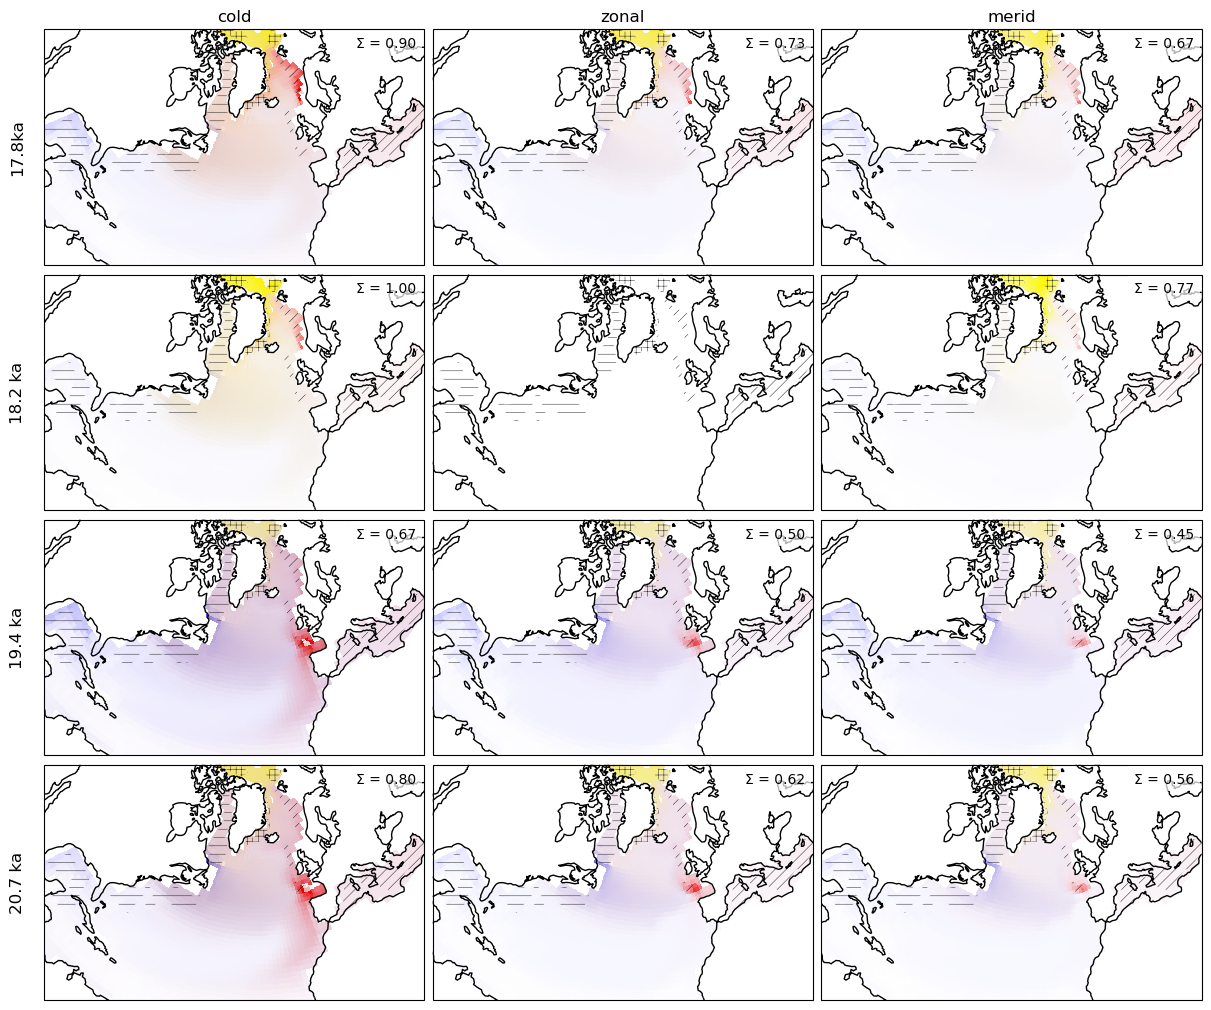

In [87]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr

scenarios = ['17.8ka','18.2 ka','19.4 ka','20.7 ka']
states = ['cold', 'zonal', 'merid']   # <-- adjust to your 3 state keys

print(max)
proj = ccrs.NorthPolarStereo(central_longitude=-30)

fig, axes = plt.subplots(len(scenarios), len(states), 
                         figsize=(4*len(states), 2.5*len(scenarios)),
                         subplot_kw={'projection': proj},
                         constrained_layout=True)

f = 8

# Global setting: all hatch edges will be black
mpl.rcParams['hatch.color'] = 'black'

dict_dye = {
    'zonal' : ds_dye_zonal,
    'merid' : ds_dye_merid,
    'cold' : ds_dye_cold }

for i, sce in enumerate(scenarios):

    for j, sta in enumerate(states):
        # prepare RGB field once per scenario
        yellow = dict_dye[sta][f'ARCTIC {sce}']/max
        red    = dict_dye[sta][f'EIS {sce}']/max
        blue   = dict_dye[sta][f'LAU {sce}']/max

        if (sta == 'zonal' and sce == '18.2 ka'):
            yellow = dict_dye[sta][f'ARCTIC {sce}']/max *0.
            red    = dict_dye[sta][f'EIS {sce}']/max * 0.
            blue   = dict_dye[sta][f'LAU {sce}']/max * 0.


        # compute sum over domain (e.g. total dye for this scenario & state)
        total_dye = float((yellow*max + red*max + blue*max).sum().values)/max_sum
    
        # clip and scale
        yellow, red, blue = [da.clip(0,1)*f for da in (yellow, red, blue)]
    
        # subtractive mixing
        R = np.ones_like(yellow)
        G = np.ones_like(yellow)
        B = np.ones_like(yellow)
        B *= (1 - yellow)
        G *= (1 - red); B *= (1 - red)
        R *= (1 - blue); G *= (1 - blue)
        rgb = np.stack([R, G, B], axis=-1)
    
        lon2d, lat2d = np.meshgrid(yellow.lon, yellow.lat)
    
        
        ax = axes[i, j]
    
        # set extent and basemap
        ax.set_extent([-95, 15, 20, 90], crs=ccrs.PlateCarree())
        ax.coastlines(color='black')
    
        # draw RGB field
        ax.pcolormesh(lon2d, lat2d, rgb, transform=ccrs.PlateCarree(), shading="nearest")
    
        # EIS
        ax.contourf(ds_region.longitude, ds_region.latitude,xr.where(ds_region['Bri'].isel(t=0).isel(depth=0)>0,ds_region['Bri'].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(),
                    levels = [0, 0.1],
                    hatches=['///'],               # hatch pattern
                    colors='none')
        
        ax.contourf(ds_region.longitude, ds_region.latitude,xr.where(ds_region['Fen'].isel(t=0).isel(depth=0)>0,ds_region['Fen'].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(),
                    levels = [0, 0.1],
                    hatches=['///'],               # hatch pattern
                    colors='none')
        
        ax.contourf(ds_region.longitude, ds_region.latitude,xr.where(ds_region['Med'].isel(t=0).isel(depth=0)>0,ds_region['Med'].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(),
                    levels = [0, 0.1],
                    hatches=['///'],               # hatch pattern
                    colors='none')
        
    
        # ARCTIC
        ax.contourf(ds_region.longitude, ds_region.latitude,xr.where(ds_region['AmeArc'].isel(t=0).isel(depth=0)>0,ds_region['AmeArc'].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(),
                    levels = [0, 0.1],
                    hatches=['+++'],               # hatch pattern
                    colors='none')
        
        ax.contourf(ds_region.longitude, ds_region.latitude,xr.where(ds_region['EurArc'].isel(t=0).isel(depth=0)>0,ds_region['EurArc'].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(),
                    levels = [0, 0.1],
                    hatches=['+++'],               # hatch pattern
                    colors='none')
        ax.contourf(ds_region.longitude, ds_region.latitude,xr.where(ds_region['GIS'].isel(t=0).isel(depth=0)>0,ds_region['GIS'].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(),
                    levels = [0, 0.1],
                    hatches=['+++'],               # hatch pattern
                    colors='none')
        
        # LAU
        cs = ax.contourf(ds_region.longitude, ds_region.latitude,xr.where(ds_region['NLau'].isel(t=0).isel(depth=0)>0,ds_region['NLau'].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(),
                    levels = [0, 0.1],
                    hatches=['--'],               # hatch pattern
                    colors='none')
        
        cs = ax.contourf(ds_region.longitude, ds_region.latitude,xr.where(ds_region['SLau'].isel(t=0).isel(depth=0)>0,ds_region['SLau'].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(),
                    levels = [0, 0.1],
                    hatches=['--'],               # hatch pattern
                    colors='none')
        cs = ax.contourf(ds_region.longitude, ds_region.latitude,xr.where(ds_region['GulofMex'].isel(t=0).isel(depth=0)>0,ds_region['GulofMex'].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(),
                    levels = [0, 0.1],
                    hatches=['--'],               # hatch pattern
                    colors='none')
        

        
        
        # add text in the upper right corner (axes fraction coordinates)
        if (total_dye != 0.):
            ax.text(0.98, 0.97,
            f"Σ = {total_dye:.2f}",
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=10, color='black',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

        
        # titles / labels
        if i == 0:
                ax.set_title(sta, fontsize=12)
        if j == 0:
                ax.text(-0.05, 0.5, sce, transform=ax.transAxes,
                        va='center', ha='right', rotation=90, fontsize=12)

   
plt.savefig('my_output/chapter-four_latestfigures/scenario_dye.pdf')
plt.show()


### Mean Fields over the North Atlantic

In [140]:
# Mean Datafields

ds_dye_zonal = xr.open_dataset('myintermediates/dyestuff_modelpaper/mean_dye_zonal.nc')
ds_dye_cold = xr.open_dataset('myintermediates/dyestuff_modelpaper/mean_dye_cold.nc')
ds_dye_merid = xr.open_dataset('myintermediates/dyestuff_modelpaper/mean_dye_merid.nc')

#landmask
with mf.Timer('Land sea mask loader'):
    data_folder = f"/nfs/annie/eeymr/work/data/publication/ROME2022_paleoceanography_oscillations"
    ds_lsm = xr.open_dataset(f"{data_folder}/lgm_inputs/temev.qrparm.omask.nc")
    lsm = ds_lsm.lsm
    lon_lsm, lat_lsm = ds_lsm.longitude.values, ds_lsm.latitude.values
    lon_lsm_b, lat_lsm_b = tb.create_coordinate_edges(lon_lsm), lat_lsm
#lsm = ds_lsm.lsm
#ds_lsm

# Regions
with mf.Timer('region data loading'):
    #for exp in exp_list:
        #try:
            ds_region = xr.open_mfdataset(f'/nfs/annie/eelse/my_ancil/dyeregions_v2_netcdf/*.nc',parallel=True)
    
            old_name=list(ds_region.data_vars)

lon_ds, lat_ds = ds_dye_cold.lon.values, ds_dye_cold.lat.values
lon_ds_b, lat_ds_b = tb.create_coordinate_edges(lon_ds), lat_ds



[Land sea mask loader]
Elapsed: 0.050550222396850586
[region data loading]
Elapsed: 0.16423916816711426


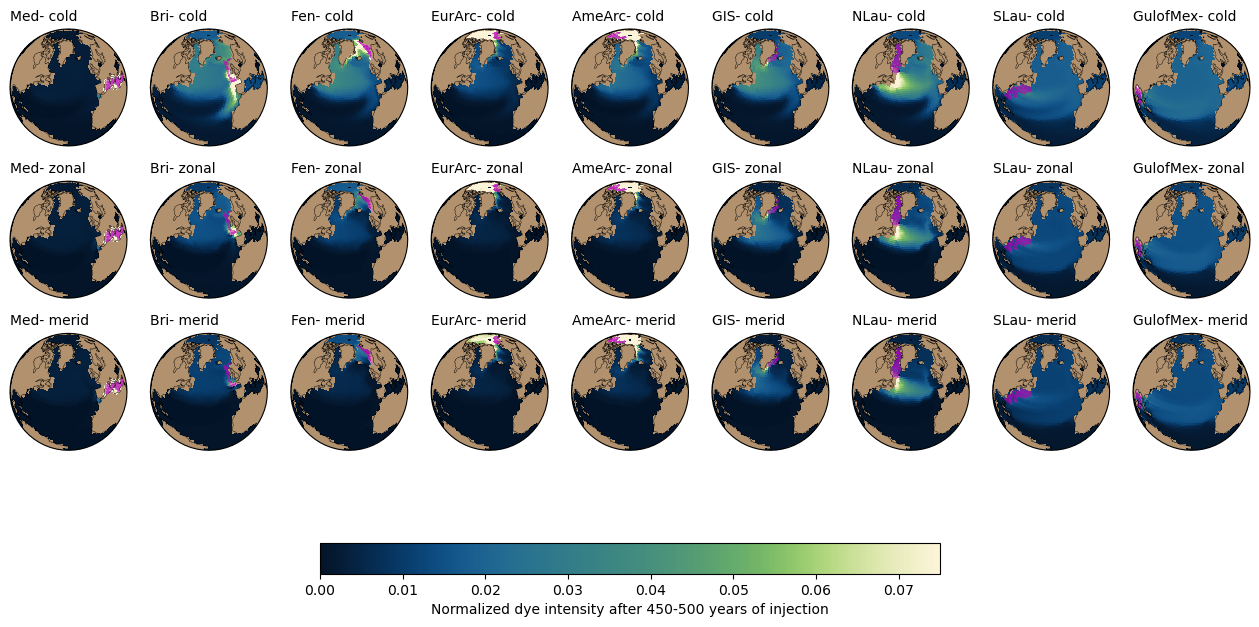

In [4]:
#### Make a plot of the three different AMOC modes, years 450-500

#Same map for all 9 scenarios & three different states, always the mean between scenarios

from matplotlib import colors

projection_map = ccrs.NearsidePerspective(central_longitude=-35, central_latitude=45, satellite_height=11000000)
normdye_a = colors.Normalize(vmin=0,vmax=0.075)

dyen = ('Med Sea','British','Fennoscandia','Eurasian Arctic','Am. Arctic','GIS','N Laurentide','S Laurentide','Gulf of Mexico')
dye_list=('dye00','dye01','dye02','dye03','dye04','dye05','dye06','dye07','dye08')
dye_names=('Med Sea','British','Fennoscandia','Eurasian Arctic','Am. Arctic','GIS','N Laurentide','S Laurentide','Gulf of Mexico')
dye_abbrev=('Med','Bri','Fen','EurArc','AmeArc','GIS','NLau','SLau','GulofMex')
states=['cold']

#Def
figMap,(axMap) = plt.subplots(nrows=3, ncols=9, subplot_kw={'projection':projection_map}, figsize=(16,8))
#axMap = axMap.flatten()
#normdye = colors.Normalize(vmin=0,vmax=0.0.075)
#normdyediff = colors.TwoSlopeNorm(vmin=-300, vcenter=0., vmax=300)


#Dye - cold state
j=0
for i in range(9):
        # Plot background land once
        axMap[j,i].pcolormesh(lsm.longitude, lsm.latitude, xr.where(lsm == 0, np.nan, lsm),
                  cmap=ListedColormap(['xkcd:pale brown']),
                  transform=ccrs.PlateCarree(),
                  zorder=1)

        # Dye mean map
        cmap = axMap[j,i].pcolormesh(lon_ds_b, lat_ds_b, ds_dye_cold[dye_list[i]],
                         transform=ccrs.PlateCarree(),
                         norm=normdye_a,
                         cmap=cmc.navia, alpha=1)

        axMap[j,i].pcolormesh(lon_ds_b, lat_ds_b,xr.where(ds_region[dye_abbrev[i]].isel(t=0).isel(depth=0)>0,ds_region[dye_abbrev[i]].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(), 
                                        clim=(0, 0.00000000001), alpha=0.5,cmap=cmc.buda_r)
        
        axMap[j,i].set_title(f'{dye_abbrev[i]}- cold',loc='left',fontsize=10)
        axMap[j,i].coastlines(resolution='110m', linewidth=0.3)


#Dye - zonal state
j=1
for i in range(9):
        # Plot background land once
        axMap[j,i].pcolormesh(lsm.longitude, lsm.latitude, xr.where(lsm == 0, np.nan, lsm),
                  cmap=ListedColormap(['xkcd:pale brown']),
                  transform=ccrs.PlateCarree(),
                  zorder=1)

        # Dye mean map
        cmap = axMap[j,i].pcolormesh(lon_ds_b, lat_ds_b, ds_dye_zonal[dye_list[i]],
                         transform=ccrs.PlateCarree(),
                         norm=normdye_a,
                         cmap=cmc.navia, alpha=1)

        axMap[j,i].pcolormesh(lon_ds_b, lat_ds_b,xr.where(ds_region[dye_abbrev[i]].isel(t=0).isel(depth=0)>0,ds_region[dye_abbrev[i]].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(), 
                                        clim=(0, 0.00000000001), alpha=0.5,cmap=cmc.buda_r)
        
        axMap[j,i].set_title(f'{dye_abbrev[i]}- zonal',loc='left',fontsize=10)
        axMap[j,i].coastlines(resolution='110m', linewidth=0.3)

#Dye - merid state
j=2
for i in range(9):
        # Plot background land once
        axMap[j,i].pcolormesh(lsm.longitude, lsm.latitude, xr.where(lsm == 0, np.nan, lsm),
                  cmap=ListedColormap(['xkcd:pale brown']),
                  transform=ccrs.PlateCarree(),
                  zorder=1)

        # Dye mean map
        cmap = axMap[j,i].pcolormesh(lon_ds_b, lat_ds_b, ds_dye_merid[dye_list[i]],
                         transform=ccrs.PlateCarree(),
                         norm=normdye_a,
                         cmap=cmc.navia, alpha=1)

        axMap[j,i].pcolormesh(lon_ds_b, lat_ds_b,xr.where(ds_region[dye_abbrev[i]].isel(t=0).isel(depth=0)>0,ds_region[dye_abbrev[i]].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(), 
                                        clim=(0, 0.00000000001), alpha=0.5,cmap=cmc.buda_r)
        
        axMap[j,i].set_title(f'{dye_abbrev[i]}- merid',loc='left',fontsize=10)
        axMap[j,i].coastlines(resolution='110m', linewidth=0.3)




#cb = figMap.colorbar(cmap, ax=axMap.ravel().tolist(), location="right", shrink=0.6, pad=20.05)

cb = plt.colorbar(cmap,ax=axMap,location="bottom",shrink=0.5)
cb.set_label(f"Normalized dye intensity after 450-500 years of injection")#, size='small')
#cb.ax.tick_params(labelsize='small')



#p#lt.subplots_adjust(wspace=0.02, hspace=0)  # Adjust to taste

#figMap.tight_layout()

#plt.savefig(f'my_output/compare_mean_amocstates.png',dpi=300,transparent=False)



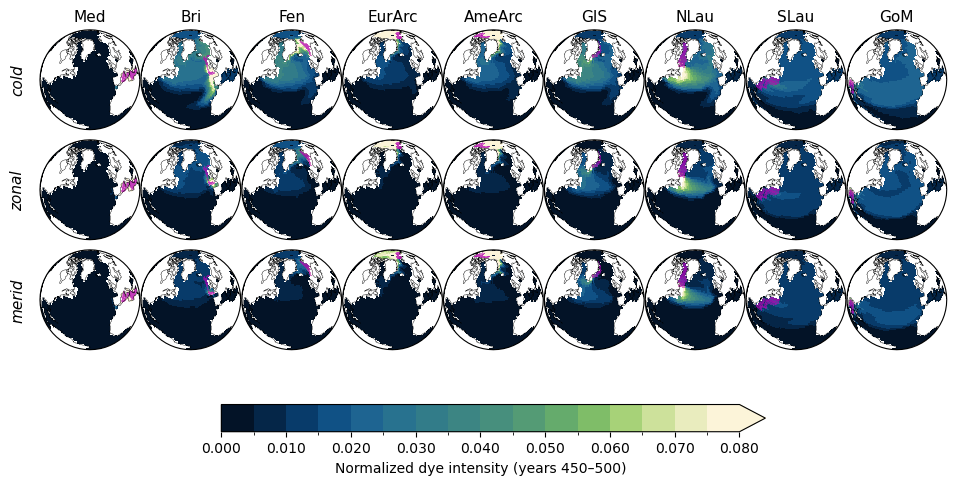

In [30]:
from matplotlib import colors
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import xarray as xr
from matplotlib.colors import ListedColormap
import matplotlib as mpl

projection_map = ccrs.NearsidePerspective(
    central_longitude=-35, central_latitude=45, satellite_height=11000000
)

# --- Discrete colormap ---
bounds = np.arange(0, 0.081, 0.005)
normdye_a = mpl.colors.BoundaryNorm(boundaries=bounds, ncolors=cmc.navia.N)


dyen = ('Med Sea','British','Fennoscandia','Eurasian Arctic',
        'Am. Arctic','GIS','N Laurentide','S Laurentide','Gulf of Mexico')
dye_list=('dye00','dye01','dye02','dye03','dye04',
          'dye05','dye06','dye07','dye08')
dye_abbrev=('Med','Bri','Fen','EurArc','AmeArc','GIS','NLau','SLau','GulofMex')
dye_abbrev_t=('Med','Bri','Fen','EurArc','AmeArc','GIS','NLau','SLau','GoM')

states = ['cold','zonal','merid']

# A4 landscape = 11.7 x 8.3 inch, add a bit of margin
figMap, axMap = plt.subplots(
    nrows=3, ncols=9, subplot_kw={'projection': projection_map},
    figsize=(11.7, 5.8)
)

for j, (ds_dye, state_name) in enumerate(zip(
        [ds_dye_cold, ds_dye_zonal, ds_dye_merid], states)):

    for i in range(9):
        # Background land
        #axMap[j, i].pcolormesh(
        #    lsm.longitude, lsm.latitude, xr.where(lsm == 0, np.nan, lsm),
        #    cmap=ListedColormap(['xkcd:pale brown']),
        #    transform=ccrs.PlateCarree(),
        #    zorder=1
        #)

        # Dye map
        cmap = axMap[j, i].pcolormesh(
            lon_ds_b, lat_ds_b, ds_dye[dye_list[i]],
            transform=ccrs.PlateCarree(),
            norm=normdye_a,
            cmap=cmc.navia, alpha=1
        )

        # Overlay source region
        axMap[j, i].pcolormesh(
            lon_ds_b, lat_ds_b,
            xr.where(ds_region[dye_abbrev[i]].isel(t=0, depth=0)>0,
                     ds_region[dye_abbrev[i]].isel(t=0, depth=0), np.nan),
            transform=ccrs.PlateCarree(),
            clim=(0, 1e-11), alpha=0.5, cmap=cmc.buda_r
        )

        axMap[j, i].coastlines(resolution='110m', linewidth=0.3)

        # Titles: top row = region names (centered)
        if j == 0:
            axMap[j, i].set_title(dye_abbrev_t[i], fontsize=11)

# --- Colorbar outside the globes ---
cb = figMap.colorbar(
    cmap, ax=axMap.ravel().tolist(),
    location="bottom", shrink=0.6, extend="max", pad=0.22,  # pad pushes it away from globes
    ticks=bounds
)
cb.set_label("Normalized dye intensity (years 450–500)")

# --- Row labels bold & larger ---
for j, state_name in enumerate(states):
    axMap[j,0].text(
        -0.15, 0.5, state_name,
        va='center', ha='right', fontsize=11,fontstyle='italic',
        rotation=90, transform=axMap[j,0].transAxes
    )

# Show only every other tick
cb.ax.set_xticks(bounds[::2])
cb.ax.set_xticklabels([f"{b:.3f}" for b in bounds[::2]])


# --- Adjust spacing for A4 landscape ---
plt.subplots_adjust(wspace=0.01, hspace=0.05, bottom=0.32)  # more bottom space for colorbar

# Save figure
# plt.savefig("compare_mean_amocstates.png", dpi=300, bbox_inches="tight")

#plt.show()




In [6]:
# --- Create global 1° grid ---
lats = np.arange(-90, 91, 1)
lons = np.arange(0, 360, 1)
ds_grid = xr.Dataset(coords={"lat": lats, "lon": lons})

# Make 2D meshgrid
lon2d, lat2d = np.meshgrid(ds_grid['lon'], ds_grid['lat'])

# --- Define masks ---
mask_dict = {}

# Arctic
mask_dict['Arctic'] = lat2d > 60

# North Atlantic: 0–80°N, 280–360°E
mask_dict['North Atlantic'] = (lat2d >= 0) & (lat2d <= 80) & (lon2d >= 280) & (lon2d <= 358)

# Gulf of Mexico: 18–31°N, 260–280°E
mask_dict['Gulf of Mexico'] = (lat2d >= 18) & (lat2d <= 31) & (lon2d >= 260) & (lon2d <= 280)

# Mediterranean: 30–45°N, -6–37°E
lon180 = np.where(lon2d > 180, lon2d - 360, lon2d)
mask_dict['Mediterranean'] = (lat2d >= 30) & (lat2d <= 45) & (lon180 >= -6) & (lon180 <= 37)


def make_region_mask(ds, lon_name="lon", lat_name="lat"):
    """Return mask (True/False) for Arctic, North Atlantic, Gulf of Mexico, Mediterranean."""
    lon = ds[lon_name].values
    lat = ds[lat_name].values
    lon2d, lat2d = np.meshgrid(lon, lat)

    # Normalize lon to 0–360 for easier selection
    lon2d = (lon2d + 360) % 360

    # Arctic: north of 60°N
    cond_arctic = lat2d > 60

    # North Atlantic: 0–80°N, 280–360°E (i.e. -80–0°W)
    cond_natl = (lat2d >= 0) & (lat2d <= 80) & (lon2d >= 280) & (lon2d <= 358) #FOR PLOTTING ONLY TO 358?

    # Gulf of Mexico: 18–31°N, 260–280°E (-100 to -80°W)
    cond_gulf = (lat2d >= 18) & (lat2d <= 31) & (lon2d >= 260) & (lon2d <= 280)

    # Mediterranean: 30–45°N, -6–37°E
    lon180 = np.where(lon2d > 180, lon2d - 360, lon2d)
    cond_med = (lat2d >= 30) & (lat2d <= 45) & (lon180 >= -6) & (lon180 <= 37)

    mask = cond_arctic | cond_natl | cond_gulf | cond_med
    return xr.DataArray(mask, dims=("lat", "lon"), coords={lat_name: lat, lon_name: lon})


# For demo, create a global 1° grid
lats = np.arange(-90, 91, 1)
lons = np.arange(0, 360, 1)
ds_grid = xr.Dataset(coords={"lat": lats, "lon": lons})

mask = make_region_mask(ds_grid)







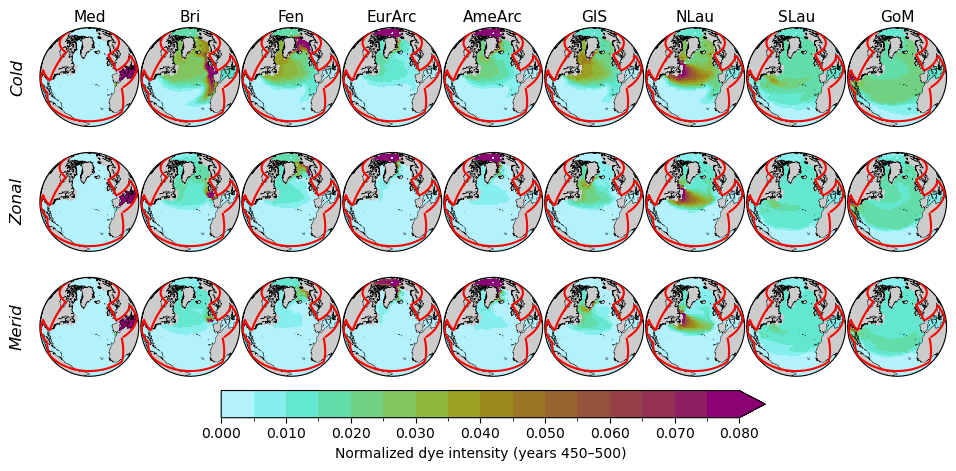

In [71]:
from matplotlib import colors
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
from matplotlib.colors import ListedColormap
import matplotlib as mpl






projection_map = ccrs.NearsidePerspective(
    central_longitude=-35, central_latitude=45, satellite_height=11000000
)

# --- Discrete colormap ---
bounds = np.arange(0, 0.081, 0.005)
normdye_a = mpl.colors.BoundaryNorm(boundaries=bounds, ncolors=cmc.hawaii_r.N)

dyen = ('Med Sea','British','Fennoscandia','Eurasian Arctic',
        'Am. Arctic','GIS','N Laurentide','S Laurentide','Gulf of Mexico')
dye_list=('dye00','dye01','dye02','dye03','dye04',
          'dye05','dye06','dye07','dye08')
dye_abbrev=('Med','Bri','Fen','EurArc','AmeArc','GIS','NLau','SLau','GulofMex')
dye_abbrev_t=('Med','Bri','Fen','EurArc','AmeArc','GIS','NLau','SLau','GoM')

states = ['Cold','Zonal','Merid']

# A4 landscape
figMap, axMap = plt.subplots(
    nrows=3, ncols=9, subplot_kw={'projection': projection_map},
    figsize=(11.7, 5.8)
)

for j, (ds_dye, state_name) in enumerate(zip(
        [ds_dye_cold, ds_dye_zonal, ds_dye_merid], states)):

    for i in range(9):
        ax = axMap[j, i]

        # Background land
        ax.pcolormesh(
            lsm.longitude, lsm.latitude, xr.where(lsm == 0, np.nan, lsm),
            cmap= ListedColormap(['#cccccc']), #ListedColormap(['#c9b299']),  # softer earth tone
            transform=ccrs.PlateCarree(),
            shading="nearest", zorder=1
        )

        # Dye map
        cmap = ax.pcolormesh(
            lon_ds_b, lat_ds_b, ds_dye[dye_list[i]],
            transform=ccrs.PlateCarree(),
            norm=normdye_a, cmap=cmc.hawaii_r, shading="nearest", alpha=1
        )

        # Overlay source region
        # --- Overlay source region with hatching ---
        #region_mask = ds_region[dye_abbrev[i]].isel(t=0, depth=0)
    
        #ax.contourf(ds_region.longitude, ds_region.latitude,xr.where(ds_region[dye_abbrev[i]].isel(t=0).isel(depth=0)>0,ds_region[dye_abbrev[i]].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(),
        #            levels = [0, 0.1],
        #            hatches=['OOOOOOOOO'],             # hatch pattern
        #            colors='white',zorder=5,alpha=0.3)
        #ax.contour(ds_region.longitude, ds_region.latitude,xr.where(ds_region[dye_abbrev[i]].isel(t=0).isel(depth=0)>0,ds_region[dye_abbrev[i]].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(),
        #            levels = [0, 0.1],
        #            hatches=['OOOOOOOOO'],               # hatch pattern
        #            colors='blue',zorder=5)

        # Overlay source region
        #axMap[j, i].pcolormesh(
        #    lon_ds_b, lat_ds_b,
        #    xr.where(ds_region[dye_abbrev[i]].isel(t=0, depth=0)>0,
        #             ds_region[dye_abbrev[i]].isel(t=0, depth=0), np.nan),
        #    transform=ccrs.PlateCarree(),
        #    clim=(0, 1e-11), alpha=0.8, cmap=cmc.imola_r
        #)

        ax.contour(ds_grid["lon"], ds_grid["lat"], mask, 
            levels=[0.5], colors="red", linewidths=1.5,zorder=6,transform=ccrs.PlateCarree())


        # Loop over masks and plot red contours
        #for region, mask in mask_dict.items():
        #    ax.contour(lon2d, lat2d, mask, levels=[0.5], colors='red', linewidths=1.5,transform=ccrs.PlateCarree())


        
        # Coastlines: higher resolution & thinner
        ax.coastlines(resolution='50m', linewidth=0.3, color="black")

        # Remove heavy globe outline
        #for spine in ax.spines.values():
        #    spine.set_visible(False)

        # Titles: top row only
        if j == 0:
            ax.set_title(dye_abbrev_t[i], fontsize=11, pad=4)

# --- Colorbar outside the globes ---
cb = figMap.colorbar(
    cmap, ax=axMap.ravel().tolist(),
    location="bottom", shrink=0.6, extend="max", pad=0.15,
    boundaries=bounds, ticks=bounds
)
cb.set_label("Normalized dye intensity (years 450–500)")

# Show every other tick
cb.ax.set_xticks(bounds[::2])
cb.ax.set_xticklabels([f"{b:.3f}" for b in bounds[::2]])

# --- Row labels italic & larger ---
for j, state_name in enumerate(states):
    axMap[j,0].text(
        -0.15, 0.5, state_name,
        va='center', ha='right', fontsize=12, fontstyle='italic',
        rotation=90, transform=axMap[j,0].transAxes
    )

# --- Adjust spacing ---
plt.subplots_adjust(wspace=0.02, hspace=0.08, bottom=0.25)

# hatsch settings
#plt.rcParams['hatch.linewidth'] = 0.3
#plt.rcParams['hatch.color'] = 'white'



# Save / show
plt.savefig("compare_mean_amocstates.pdf", dpi=300, bbox_inches="tight")
plt.savefig("compare_mean_amocstates.png",dpi=300)

#plt.show()


In [63]:
lsm

<xarray.DataArray 'lsm' (latitude: 144, longitude: 288)>
array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 1., 1., ..., 1., 1., 1.]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * latitude   (latitude) float32 -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
Attributes:
    long_name:  Ocean model land/sea mask
    units:      0-1

In [141]:
ds_dye.data_vars

Data variables:
    dye00    (lat, lon) float32 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    dye01    (lat, lon) float32 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    dye02    (lat, lon) float32 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    dye03    (lat, lon) float32 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    dye04    (lat, lon) float32 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    dye05    (lat, lon) float32 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    dye06    (lat, lon) float32 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    dye07    (lat, lon) float32 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    dye08    (lat, lon) float32 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

In [143]:
#eps = np.spacing(0.0)
ds_dye[dye_list[i]].clip(min=eps)  #.isel(t=0,depth=0)
#ds_dye[dye_abbrev[i]].clip(min=eps)

<xarray.DataArray 'dye00' (lat: 144, lon: 288)>
array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [0.00144859, 0.00144678, 0.00144489, ..., 0.00145339, 0.00145191,
        0.0014503 ],
       [0.00143028, 0.00142932, 0.00142834, ..., 0.00143305, 0.00143215,
        0.00143123],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], dtype=float32)
Coordinates:
  * lat      (lat) float32 -89.38 -88.12 -86.88 -85.62 ... 86.88 88.12 89.38
  * lon      (lon) float32 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8

In [188]:
for i, p in enumerate(polygons):
    print(i, p.is_valid, p.is_empty, p.geom_type)

0 True False Polygon
1 True False Polygon


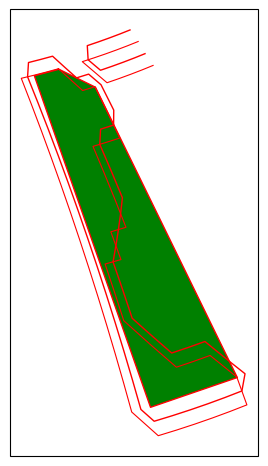

In [205]:
# Different approach for region boundaries
contours = measure.find_contours(mask, level=0.5)
from shapely.geometry import Polygon
from scipy.spatial import Delaunay


def alpha_shape(points, alpha):
    if len(points) < 4:
        return MultiPoint(points).convex_hull

    tri = Delaunay(points)
    edges = []

    for ia, ib, ic in tri.simplices:
        pa, pb, pc = points[ia], points[ib], points[ic]

        a = np.linalg.norm(pa - pb)
        b = np.linalg.norm(pb - pc)
        c = np.linalg.norm(pc - pa)

        s = (a + b + c) / 2.0
        area = max(s * (s - a) * (s - b) * (s - c), 1e-12)

        circum_r = (a * b * c) / (4.0 * np.sqrt(area))

        if circum_r < alpha:
            edges.extend([(ia, ib), (ib, ic), (ic, ia)])

    # build polygon from boundary points
    edge_points = points[np.unique(np.array(edges).flatten())]
    return MultiPoint(edge_points).convex_hull


projection_map = ccrs.PlateCarree()
projection_map = ccrs.NearsidePerspective(
    central_longitude=-35, central_latitude=45, satellite_height=11000000
)


# A4 landscape
figMap, ax = plt.subplots(
    nrows=1, ncols=1, subplot_kw={'projection': projection_map},
    figsize=(5.8, 5.8)
)


i = 1
ds_dye_region = xr.open_dataset('myintermediates/dyestuff_modelpaper/dye_regions_norm.nc')
mask = xr.where(ds_dye_region[dye_abbrev[i]].isel(t=0, depth=0) > 0, 1, 0).values

from skimage import measure

contours = measure.find_contours(mask, 0.5)

polygons = []

for c in contours:
    lon_c = lon_lsm[c[:,1].astype(int)]
    lat_c = lat_lsm[c[:,0].astype(int)]

    coords = np.column_stack([lon_c, lat_c])

    if len(coords) > 3:
        polygons.append(coords)


for poly in polygons:
    ax.plot(
        poly[:,0],
        poly[:,1],
        transform=ccrs.PlateCarree(),
        color='red',
        linewidth=0.8,
        zorder=20
    )

from shapely.geometry import MultiPoint

lon_fixed = np.where(lon_lsm > 180, lon_lsm - 360, lon_lsm)

lon2d, lat2d = np.meshgrid(lon_fixed, lat_lsm)

points = np.column_stack([
    lon2d[mask == 1],
    lat2d[mask == 1]
])

#poly = Polygon(coords)

#poly = MultiPoint(points).convex_hull

poly = alpha_shape(points, alpha=1)

ax.add_geometries(
    [poly],
    crs=ccrs.PlateCarree(),
    edgecolor='red',
    facecolor='green'
)


ax.contour(
    lon_lsm,
    lat_lsm,
    mask,
    levels=[0.5],
    colors='red',
    linewidths=1.0,
    transform=ccrs.PlateCarree()
)




In [198]:
print(poly)
print(poly.bounds)

POLYGON ((347.5 46.875, 347.5 61.875, 358.75 61.875, 353.75 46.875, 347.5 46.875))
(347.5, 46.875, 358.75, 61.875)


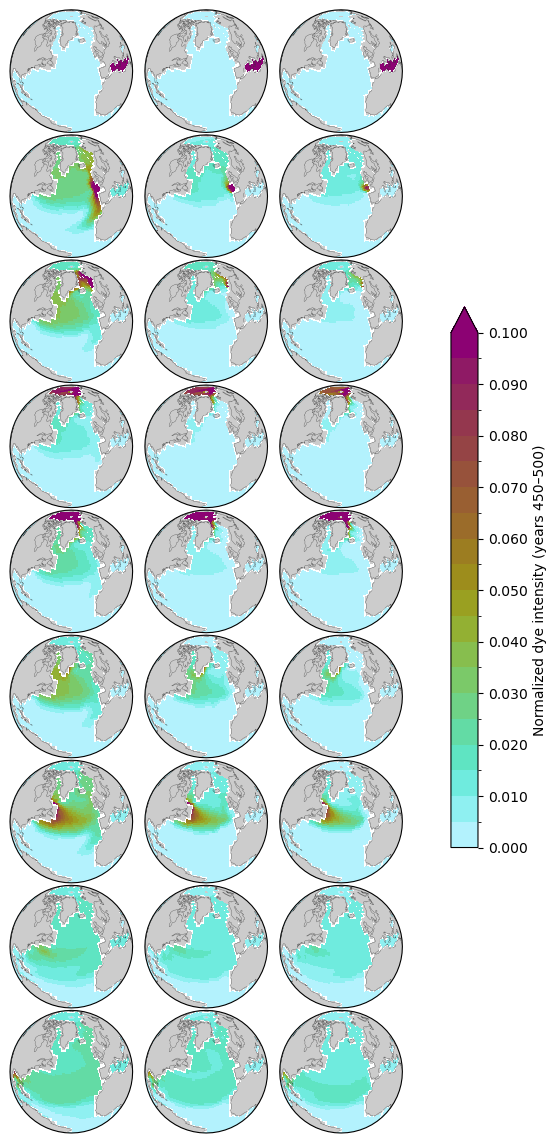

In [209]:
# Revison Edits

from matplotlib import colors
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
from matplotlib.colors import ListedColormap
import matplotlib as mpl
import matplotlib.path as mpath
import matplotlib.patches as mpatches
from scipy.ndimage import gaussian_filter



projection_map = ccrs.NearsidePerspective(
    central_longitude=-35, central_latitude=45, satellite_height=11000000
)


projection_map = ccrs.Robinson()
projection_map = ccrs.NearsidePerspective(central_longitude=-35, central_latitude=45, satellite_height=11000000)


#Regions
ds_dye_region = xr.open_dataset('myintermediates/dyestuff_modelpaper/dye_regions_norm.nc')


# --- Discrete colormap ---
bounds = np.arange(0, 0.101, 0.005)
normdye_a = mpl.colors.BoundaryNorm(boundaries=bounds, ncolors=cmc.hawaii_r.N)

dyen = ('Med Sea','British','Fennoscandia','Eurasian Arctic',
        'Am. Arctic','GIS','N Laurentide','S Laurentide','Gulf of Mexico')
dye_list=('dye00','dye01','dye02','dye03','dye04',
          'dye05','dye06','dye07','dye08')
dye_abbrev=('Med','Bri','Fen','EurArc','AmeArc','GIS','NLau','SLau','GulofMex')
dye_abbrev_t=('Med','Bri','Fen','EurArc','AmeArc','GIS','NLau','SLau','GoM')

states = ['Cold','Zonal','Merid']

# A4 landscape
figMap, axMap = plt.subplots(
    nrows=9, ncols=3, subplot_kw={'projection': projection_map},
    figsize=(5.8, 11.7)
)

for j, (ds_dye, state_name) in enumerate(zip(
        [ds_dye_cold, ds_dye_zonal, ds_dye_merid], states)):

    for i in range(9):
        ax = axMap[i, j]

        
        # Dye map

        # Background land
        ax.pcolormesh(
            ds_lsm.longitude, ds_lsm.latitude, 
            xr.where(ds_lsm.lsm == 0, np.nan, ds_lsm.lsm),
            cmap= ListedColormap(['#cccccc']), #ListedColormap(['#c9b299']),  # softer earth tone
            transform=ccrs.PlateCarree(),
            shading="nearest", zorder=1
        )

        #data = ds_dye[dye_list[i]].values

        #data_smooth = gaussian_filter(data, sigma=1.0)
        
        cmap = ax.pcolormesh(
            lon_ds_b, lat_ds_b, ds_dye[dye_list[i]].rolling(
    lat=3, lon=3, center=True
).mean(),
            transform=ccrs.PlateCarree(),
            norm=normdye_a, cmap=cmc.hawaii_r, shading="nearest", alpha=1
        )


        ax.coastlines(resolution='110m', linewidth=0.25, color='0.2', alpha=0.8,zorder=4)


# --- Colorbar outside the globes ---
cb = figMap.colorbar(
    cmap, ax=axMap.ravel().tolist(),
    location="right", shrink=0.6, extend="max", pad=0.15,
    boundaries=bounds, ticks=bounds
)
cb.set_label("Normalized dye intensity (years 450–500)")

# Show every other tick
cb.ax.set_yticks(bounds[::2])
cb.ax.set_yticklabels([f"{b:.3f}" for b in bounds[::2]])

# --- Adjust spacing ---
plt.subplots_adjust(wspace=-0.01, hspace=0.02, top=0.98, bottom=0.02, left = 0, right = 0.7)

# All Annotations will be done in illustrator
# Save / show
plt.savefig("compare_mean_amocstates_rev.pdf", dpi=600, bbox_inches="tight")
#plt.savefig("compare_mean_amocstates.png",dpi=300)

#plt.show()


### Temporal For Scenario 17.8k xpraj: make the colored dyes for several snapshots

In [111]:
#cold mode 17.8k)
exp = 'xpraj'
ds_dye = {}

with mf.Timer('data loading'):
    #for exp in exp_list:
        ds_dye = xr.open_mfdataset(f'/nfs/annie/earpal/database/experiments/{exp}/time_series/{exp}.dye0?.annual.nc',parallel=True)

        old_name=list(ds_dye.data_vars)
        ds_dye = ds_dye.rename_vars({old_name[0]: 'dye00',
                                        old_name[1]: 'dye01',
                                        old_name[2]: 'dye02',
                                        old_name[3]: 'dye03',
                                        old_name[4]: 'dye04',
                                        old_name[5]: 'dye05',
                                        old_name[6]: 'dye06',
                                        old_name[7]: 'dye07',
                                        old_name[8]: 'dye08',
                                        #old_name[9]: 'dye09',
                                              }
                                             )

# Make the three groups
ds_dye['EIS'] = ds_dye['dye01'] + ds_dye['dye02']  + ds_dye['dye00'] 
ds_dye['ARCTIC'] = ds_dye['dye03'] + ds_dye['dye04']+ ds_dye['dye05'] 
ds_dye['LAU'] = ds_dye['dye06'] + ds_dye['dye07'] + ds_dye['dye08']



[data loading]
Elapsed: 0.1705474853515625


In [115]:
# Percentages of the total signal , apply to ds_dye xpraj
import pandas as pd
gdg = pd.read_pickle("myintermediates/regionalmeltdischarge_withd18O.pkl") # source region d18O

for sce in ['17.8ka','18.2 ka','19.4 ka','20.7 ka']:
    gdg[f'Meltfraction {sce}'] = gdg[f'Region Melt {sce} (Sv)']/gdg[f'Region Melt {sce} (Sv)'].sum()


sce = '17.8ka'

ds_dye[f'EIS {sce}'] = gdg.loc[gdg.Name == 'British', f'Meltfraction {sce}'].iloc[0]*ds_dye['dye01'] + gdg.loc[gdg.Name == 'Fennoscandia', f'Meltfraction {sce}'].iloc[0]*ds_dye['dye02']  + gdg.loc[gdg.Name == 'Mediterranean', f'Meltfraction {sce}'].iloc[0]*ds_dye['dye00'] 
ds_dye[f'ARCTIC {sce}'] = gdg.loc[gdg.Name == 'Eurasian Arctic', f'Meltfraction {sce}'].iloc[0]*ds_dye['dye03'] + gdg.loc[gdg.Name == 'American Arctic', f'Meltfraction {sce}'].iloc[0]*ds_dye['dye04']+ gdg.loc[gdg.Name == 'GIS', f'Meltfraction {sce}'].iloc[0]*ds_dye['dye05'] 
ds_dye[f'LAU {sce}'] = gdg.loc[gdg.Name == 'N Laurentide', f'Meltfraction {sce}'].iloc[0]*ds_dye['dye06'] + gdg.loc[gdg.Name == 'S Laurentide', f'Meltfraction {sce}'].iloc[0]*ds_dye['dye07'] + gdg.loc[gdg.Name == 'Gulf of Mexico', f'Meltfraction {sce}'].iloc[0]*ds_dye['dye08']


In [151]:
# Range Computations (I think they are later neglected?)
max = ds_dye[f'ARCTIC {sce}'].max()
max_sum = ds_dye[f'ARCTIC {sce}'] + ds_dye[f'EIS {sce}'] + ds_dye[f'LAU {sce}']

#total_dye = float((yellow*max + red*max + blue*max).sum().values)/max_sum
max_sum_v = max_sum.isel(depth_1=0).sum(dim=['latitude','longitude']).max().values
max_sum_v

#total_dye = float((yellow*max + red*max + blue*max).sum().values)/max_sum_v
max = ds_dye[f'ARCTIC {sce}'].isel(depth_1=0).sum(dim=['latitude','longitude']).max().values


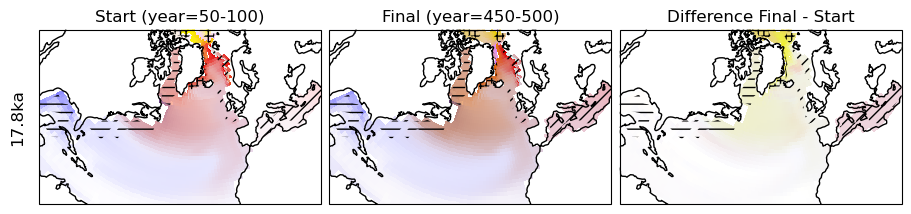

In [195]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr

times = [50, 175, 300, 425]
sce = '17.8ka'

proj = ccrs.NorthPolarStereo(central_longitude=-30)

fig, axes = plt.subplots(
    1, 3,
    figsize=(9, 6),
    subplot_kw={'projection': proj},
    constrained_layout=True
)

mpl.rcParams['hatch.color'] = 'black'

f = 5000


start_yellow = ds_dye[f'ARCTIC {sce}'].isel(t=slice(50, 100), depth_1=0).mean(dim='t')/max
start_red    = ds_dye[f'EIS {sce}'].isel(t=slice(50, 100), depth_1=0).mean(dim='t')/max
start_blue   = ds_dye[f'LAU {sce}'].isel(t=slice(50, 100), depth_1=0).mean(dim='t')/max

final_yellow = ds_dye[f'ARCTIC {sce}'].isel(t=slice(450, 500), depth_1=0).mean(dim='t')/max
final_red    = ds_dye[f'EIS {sce}'].isel(t=slice(450, 500), depth_1=0).mean(dim='t')/max
final_blue   = ds_dye[f'LAU {sce}'].isel(t=slice(450, 500), depth_1=0).mean(dim='t')/max



lon2d, lat2d = np.meshgrid(start_yellow.longitude, start_yellow.latitude)

#Start 
ax = axes[0]
yellow = start_yellow
red    = start_red
blue   = start_blue

# compute sum over domain (e.g. total dye for this scenario & state)
#total_dye = float((yellow.sum()*max + red.sum()*max + blue.sum()*max))/max_sum_v

# clip and scale
yellow, red, blue = [da.clip(0, 1)*f for da in (yellow, red, blue)]

# subtractive mixing (stay inside xarray land)
R = (1 - blue)
G = (1 - red) * (1 - blue)
B = (1 - yellow) * (1 - red)
# stack into RGB (DataArray, dim "band")
rgb = xr.concat([R, G, B], dim="band")
# convert for plotting: (lat, lon, 3)
rgb_np = np.moveaxis(rgb.values, 0, -1)
    

ax.set_extent([-95, 15, 20, 90], crs=ccrs.PlateCarree())
ax.coastlines(color='black')

# plot RGB
ax.pcolormesh(lon2d, lat2d, rgb_np, transform=ccrs.PlateCarree(), shading="nearest")

ax.set_title(f'Start (year=50-100)', fontsize=12)

ax.text(-0.05, 0.5, sce, transform=ax.transAxes,
                     va='center', ha='right', rotation=90, fontsize=12)


#Final
ax = axes[1]
yellow = final_yellow
red    = final_red
blue   = final_blue

# compute sum over domain (e.g. total dye for this scenario & state)
#total_dye = float((yellow.sum()*max + red.sum()*max + blue.sum()*max))/max_sum_v

# clip and scale
yellow, red, blue = [da.clip(0, 1)*f for da in (yellow, red, blue)]

# subtractive mixing (stay inside xarray land)
R = (1 - blue)
G = (1 - red) * (1 - blue)
B = (1 - yellow) * (1 - red)
# stack into RGB (DataArray, dim "band")
rgb = xr.concat([R, G, B], dim="band")
# convert for plotting: (lat, lon, 3)
rgb_np = np.moveaxis(rgb.values, 0, -1)
    

ax.set_extent([-95, 15, 20, 90], crs=ccrs.PlateCarree())
ax.coastlines(color='black')

# plot RGB
ax.pcolormesh(lon2d, lat2d, rgb_np, transform=ccrs.PlateCarree(), shading="nearest")

ax.set_title(f'Final (year=450-500)', fontsize=12)


#Difference
ax = axes[2]
yellow = final_yellow-start_yellow
red    = final_red-start_red
blue   = final_blue-start_blue

# compute sum over domain (e.g. total dye for this scenario & state)
#total_dye = float((yellow.sum()*max + red.sum()*max + blue.sum()*max))/max_sum_v

# clip and scale
yellow, red, blue = [da.clip(0, 1)*f for da in (yellow, red, blue)]

# subtractive mixing (stay inside xarray land)
R = (1 - blue)
G = (1 - red) * (1 - blue)
B = (1 - yellow) * (1 - red)
# stack into RGB (DataArray, dim "band")
rgb = xr.concat([R, G, B], dim="band")
# convert for plotting: (lat, lon, 3)
rgb_np = np.moveaxis(rgb.values, 0, -1)
    

ax.set_extent([-95, 15, 20, 90], crs=ccrs.PlateCarree())
ax.coastlines(color='black')

# plot RGB
ax.pcolormesh(lon2d, lat2d, rgb_np, transform=ccrs.PlateCarree(), shading="nearest")

ax.set_title(f'Difference Final - Start', fontsize=12)



for ax in axes:
        # EIS
        ax.contourf(ds_region.longitude, ds_region.latitude,xr.where(ds_region['Bri'].isel(t=0).isel(depth=0)>0,ds_region['Bri'].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(),
                    levels = [0, 0.1],
                    hatches=['///'],               # hatch pattern
                    colors='none')
        
        ax.contourf(ds_region.longitude, ds_region.latitude,xr.where(ds_region['Fen'].isel(t=0).isel(depth=0)>0,ds_region['Fen'].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(),
                    levels = [0, 0.1],
                    hatches=['///'],               # hatch pattern
                    colors='none')
        
        ax.contourf(ds_region.longitude, ds_region.latitude,xr.where(ds_region['Med'].isel(t=0).isel(depth=0)>0,ds_region['Med'].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(),
                    levels = [0, 0.1],
                    hatches=['///'],               # hatch pattern
                    colors='none')
        
    
        # ARCTIC
        ax.contourf(ds_region.longitude, ds_region.latitude,xr.where(ds_region['AmeArc'].isel(t=0).isel(depth=0)>0,ds_region['AmeArc'].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(),
                    levels = [0, 0.1],
                    hatches=['+++'],               # hatch pattern
                    colors='none')
        
        ax.contourf(ds_region.longitude, ds_region.latitude,xr.where(ds_region['EurArc'].isel(t=0).isel(depth=0)>0,ds_region['EurArc'].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(),
                    levels = [0, 0.1],
                    hatches=['+++'],               # hatch pattern
                    colors='none')
        ax.contourf(ds_region.longitude, ds_region.latitude,xr.where(ds_region['GIS'].isel(t=0).isel(depth=0)>0,ds_region['GIS'].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(),
                    levels = [0, 0.1],
                    hatches=['+++'],               # hatch pattern
                    colors='none')
        
        # LAU
        cs = ax.contourf(ds_region.longitude, ds_region.latitude,xr.where(ds_region['NLau'].isel(t=0).isel(depth=0)>0,ds_region['NLau'].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(),
                    levels = [0, 0.1],
                    hatches=['--'],               # hatch pattern
                    colors='none')
        
        cs = ax.contourf(ds_region.longitude, ds_region.latitude,xr.where(ds_region['SLau'].isel(t=0).isel(depth=0)>0,ds_region['SLau'].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(),
                    levels = [0, 0.1],
                    hatches=['--'],               # hatch pattern
                    colors='none')
        cs = ax.contourf(ds_region.longitude, ds_region.latitude,xr.where(ds_region['GulofMex'].isel(t=0).isel(depth=0)>0,ds_region['GulofMex'].isel(t=0).isel(depth=0),np.nan), transform=ccrs.PlateCarree(),
                    levels = [0, 0.1],
                    hatches=['--'],               # hatch pattern
                    colors='none')




plt.savefig('my_output/chapter-four_latestfigures/scenario_dye_evolve.pdf')
# plt.show()
